# Wen et al. 1D Data: Path Lifting & Analysis

This notebook demonstrates the full pipeline on real 1D grid cell data from Wen et al.:
1. Load spike data and position from the Wen dataset
2. Perform spectral analysis to identify grid cell modules
3. Extract toroidal coordinates and apply path lifting
4. Segment the 1D trajectory by laps and compute per-segment mismatch scores
5. Visualize reconstruction quality across segments

In [ ]:
import os, sys
sys.path.append('..')

import math
import numpy as np
import matplotlib.pyplot as plt
import scipy.io as sio

from constants import WEN_DATA_PATH
from Wen_data_test.Wen_utils import convert_raw_data, spectral_analysis
from toroidal_coordinates.compute_coord import interp_arr
from toroidal_coordinates.toroidal_lifting import toroidal_lifting_distance_upgrade
from affine_transform.get_transform_mat import get_transform_mat, apply_transform_mat
from pipelines import (
    recover_traj_pipeline,
    compare_lifted_pipeline,
    compare_lifted_1d_pipeline,
    segmental_compare_1d_pipeline,
    plot_trajectory_comparison,
)

## 1. Load Wen Data

Using session `N2_200203_buildup_track` from the Wen et al. dataset (1D linear track).

In [2]:
FNAME = 'N2_200203_buildup_track'

mat_data = sio.loadmat(os.path.join(WEN_DATA_PATH, FNAME + '.mat'))
print(f"Keys: {list(mat_data.keys())}")

position = mat_data['posx'][:, 0]
post = mat_data['post'][:, 0]
print(f"Position shape: {position.shape}, Time shape: {post.shape}")
print(f"All maps shape: {mat_data['all_maps'].shape}  (n_cells x n_trials x n_spatial_bins)")

Keys: ['__header__', '__version__', '__globals__', 'all_maps', 'lickt', 'lickx', 'post', 'posx', 'trial_starts', 'clu_ids', 'sp']
Position shape: (209275,), Time shape: (209275,)
All maps shape: (201, 619, 160)  (n_cells x n_trials x n_spatial_bins)


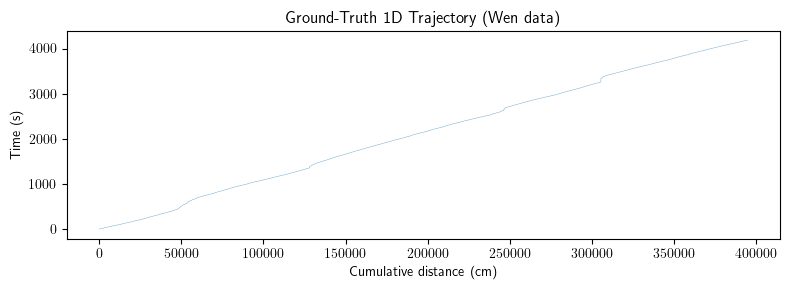

In [3]:
# Build cumulative-distance trajectory so laps concatenate continuously
cumulative_dist = np.cumsum(np.abs(np.diff(position)))
cumulative_dist = np.insert(cumulative_dist, 0, 0.0)

# Visualize the 1D trajectory (cumulative distance vs time)
fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(cumulative_dist, post, linewidth=0.3, alpha=0.7)
ax.set_xlabel('Cumulative distance (cm)')
ax.set_ylabel('Time (s)')
ax.set_title('Ground-Truth 1D Trajectory (Wen data)')
plt.tight_layout()
plt.show()

## 2. Spectral Analysis & Grid Cell Module Selection

Use spectral analysis to cluster neurons into grid cell modules, then select the first (finest scale) module.

In [4]:
maps_data = convert_raw_data(mat_data, FNAME)
results = spectral_analysis(maps_data)
grid_cell_idxs_modules = results.grid_cell_idxs_modules

print(f"Number of modules: {len(grid_cell_idxs_modules)}")
for i, idxs in enumerate(grid_cell_idxs_modules):
    print(f"  Module {i}: {len(idxs)} cells")

201 cells, 619 trials, 160 spatial bins
Identified 5 candidate modules
Number of modules: 5
  Module 0: 44 cells
  Module 1: 31 cells
  Module 2: 12 cells
  Module 3: 19 cells
  Module 4: 21 cells


In [5]:
# Use module 0 (finest scale) — reshape to (n_cells, n_trials * n_spatial_bins)
m1 = mat_data['all_maps'][grid_cell_idxs_modules[0]]
all_m1 = np.reshape(m1, (m1.shape[0], m1.shape[1] * m1.shape[2]))
print(f"Activity matrix shape: {all_m1.shape}  (n_cells x n_timepoints)")

Activity matrix shape: (44, 99040)  (n_cells x n_timepoints)


## 3. Extract Toroidal Coordinates & Apply Path Lifting

In [6]:
# recover_traj_pipeline expects activity in shape (n_cells, n_timesteps)
tor_coord, lifted = recover_traj_pipeline(all_m1)

print(f"Toroidal coord shape: {tor_coord.shape}")
print(f"Lifted coord shape:   {lifted.shape}")

dreimac failed, falling back to gardner


/home/hyoon/GridCellDecoding/example/../toroidal_coordinates/Gardner_toroidal.py:148: RuntimeWarning: divide by zero encountered in log
  d = -np.log(d)


DISTANCE_THRESHOLD: 0.20700955874350147
Toroidal coord shape: (98784, 2)
Lifted coord shape:   (98784, 2)


In [7]:
# TO REMOVE LATER
# check. We want 2pi - delta to be close to epsilon
from toroidal_coordinates.epsilon import compute_epsilon, compute_delta

delta = compute_delta(tor_coord)
epsilon = compute_epsilon(tor_coord)

print("delta:", delta)
print("2 pi - delta:", 2 * np.pi - delta)
print("epsilon:", epsilon)

delta: 5.143760710084937
2 pi - delta: 1.1394245970946493
epsilon: 1.1422373967596458


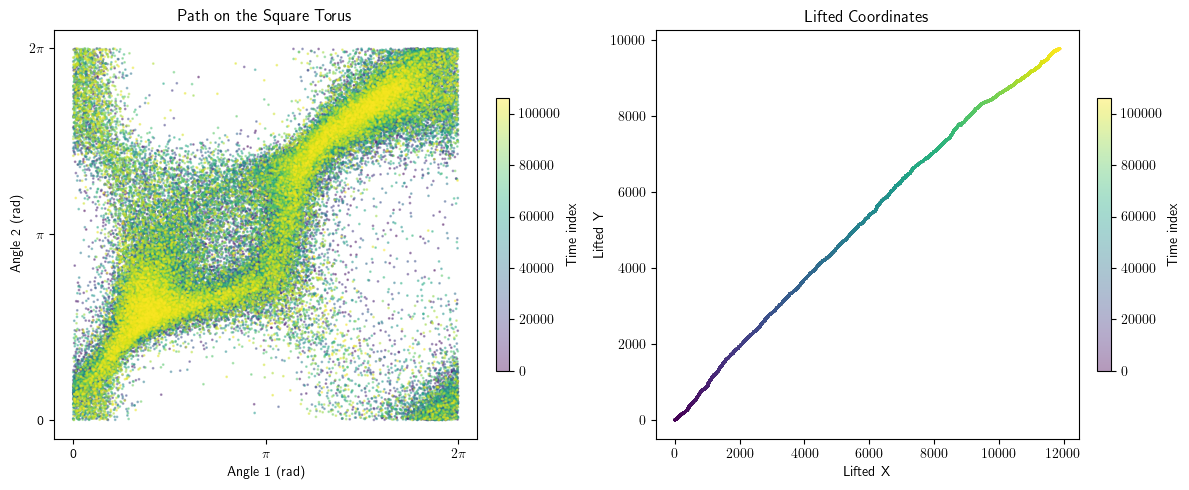

In [8]:
# Interpolate position and time to match lifted coordinate length
position_interp = interp_arr(position, lifted.shape[0])
post_interp = interp_arr(post, lifted.shape[0])

# Build the ground-truth trajectory as (position, time) pairs
time_path = np.column_stack((position_interp, post_interp))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Toroidal coordinates on the square torus
sc = axes[0].scatter(tor_coord[:, 0], tor_coord[:, 1], c=np.arange(len(tor_coord)),
                     cmap='viridis', s=1, alpha=0.4)
axes[0].set_xlabel('Angle 1 (rad)')
axes[0].set_ylabel('Angle 2 (rad)')
axes[0].set_title('Path on the Square Torus')
axes[0].set_xticks([0, math.pi, 2 * math.pi])
axes[0].set_xticklabels(['0', r'$\pi$', r'$2\pi$'])
axes[0].set_yticks([0, math.pi, 2 * math.pi])
axes[0].set_yticklabels(['0', r'$\pi$', r'$2\pi$'])
plt.colorbar(sc, ax=axes[0], label='Time index', fraction=0.03, pad=0.04)

# Lifted coordinates
sc2 = axes[1].scatter(lifted[:, 0], lifted[:, 1], c=np.arange(len(lifted)),
                      cmap='viridis', s=1, alpha=0.4)
axes[1].set_xlabel('Lifted X')
axes[1].set_ylabel('Lifted Y')
axes[1].set_title('Lifted Coordinates')
plt.colorbar(sc2, ax=axes[1], label='Time index', fraction=0.03, pad=0.04)

plt.tight_layout()
plt.show()

## 4. Overall Mismatch Score

In [9]:
# Interpolate cumulative distance to match lifted coordinate length
cumulative_dist_interp = interp_arr(cumulative_dist, lifted.shape[0])

original_coord = np.column_stack((cumulative_dist_interp, cumulative_dist_interp))

lifted_transformed, overall_score = compare_lifted_1d_pipeline(lifted, original_coord)
print(f"Overall mismatch score: {overall_score:.6f}")

# Segmental mismatch
LEN_SEG = 1000
seg_scores = segmental_compare_1d_pipeline(lifted, original_coord, LEN_SEG)

Mismatch score: 0.05934922229038214
Overall mismatch score: 0.059349
Segmental 1D mismatch scores: mean=0.103792, std=0.074290


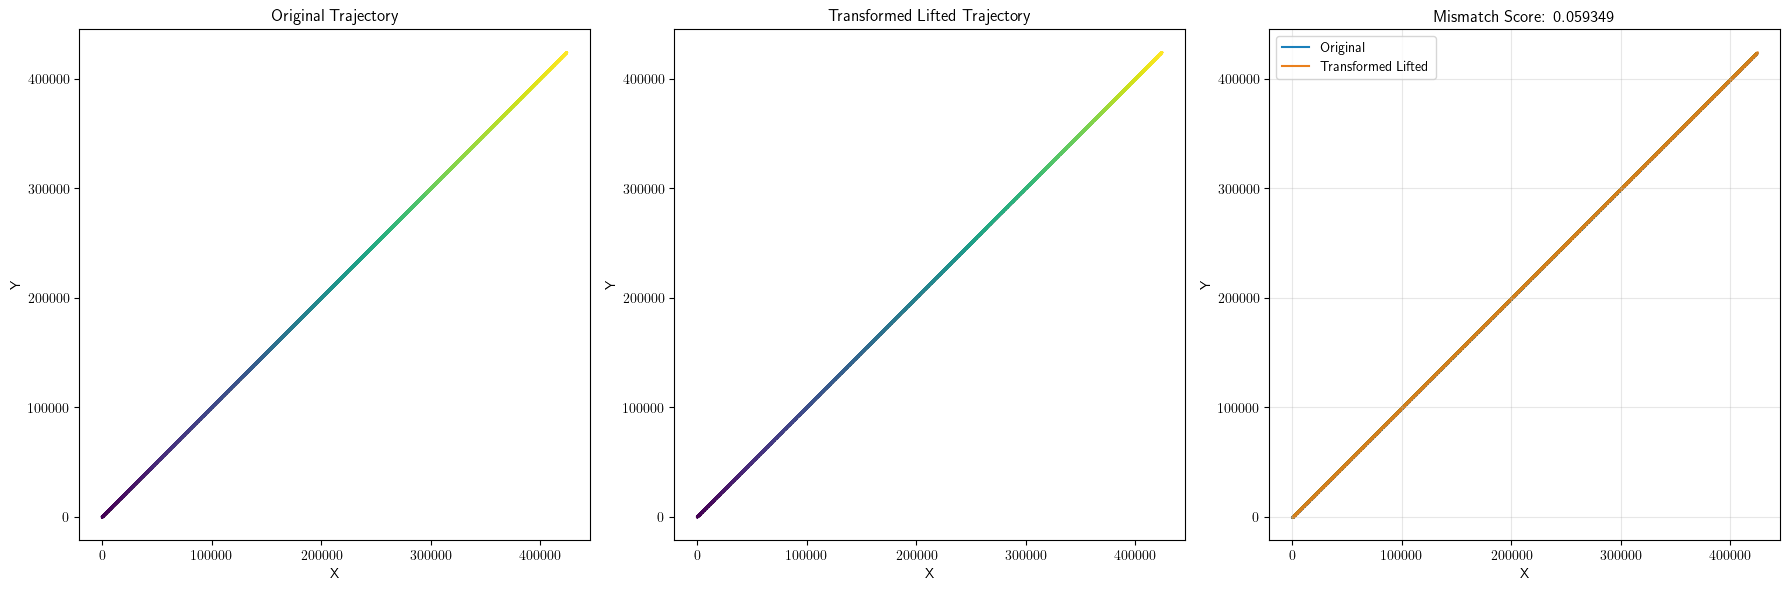

In [10]:
plot_trajectory_comparison(original_coord, lifted_transformed, score=overall_score)

In [11]:
lifted_coord_transformed, score = compare_lifted_pipeline(lifted, time_x_target, method='LS')
print(f"Overall mismatch score: {score:.6f}")

NameError: name 'time_x_target' is not defined

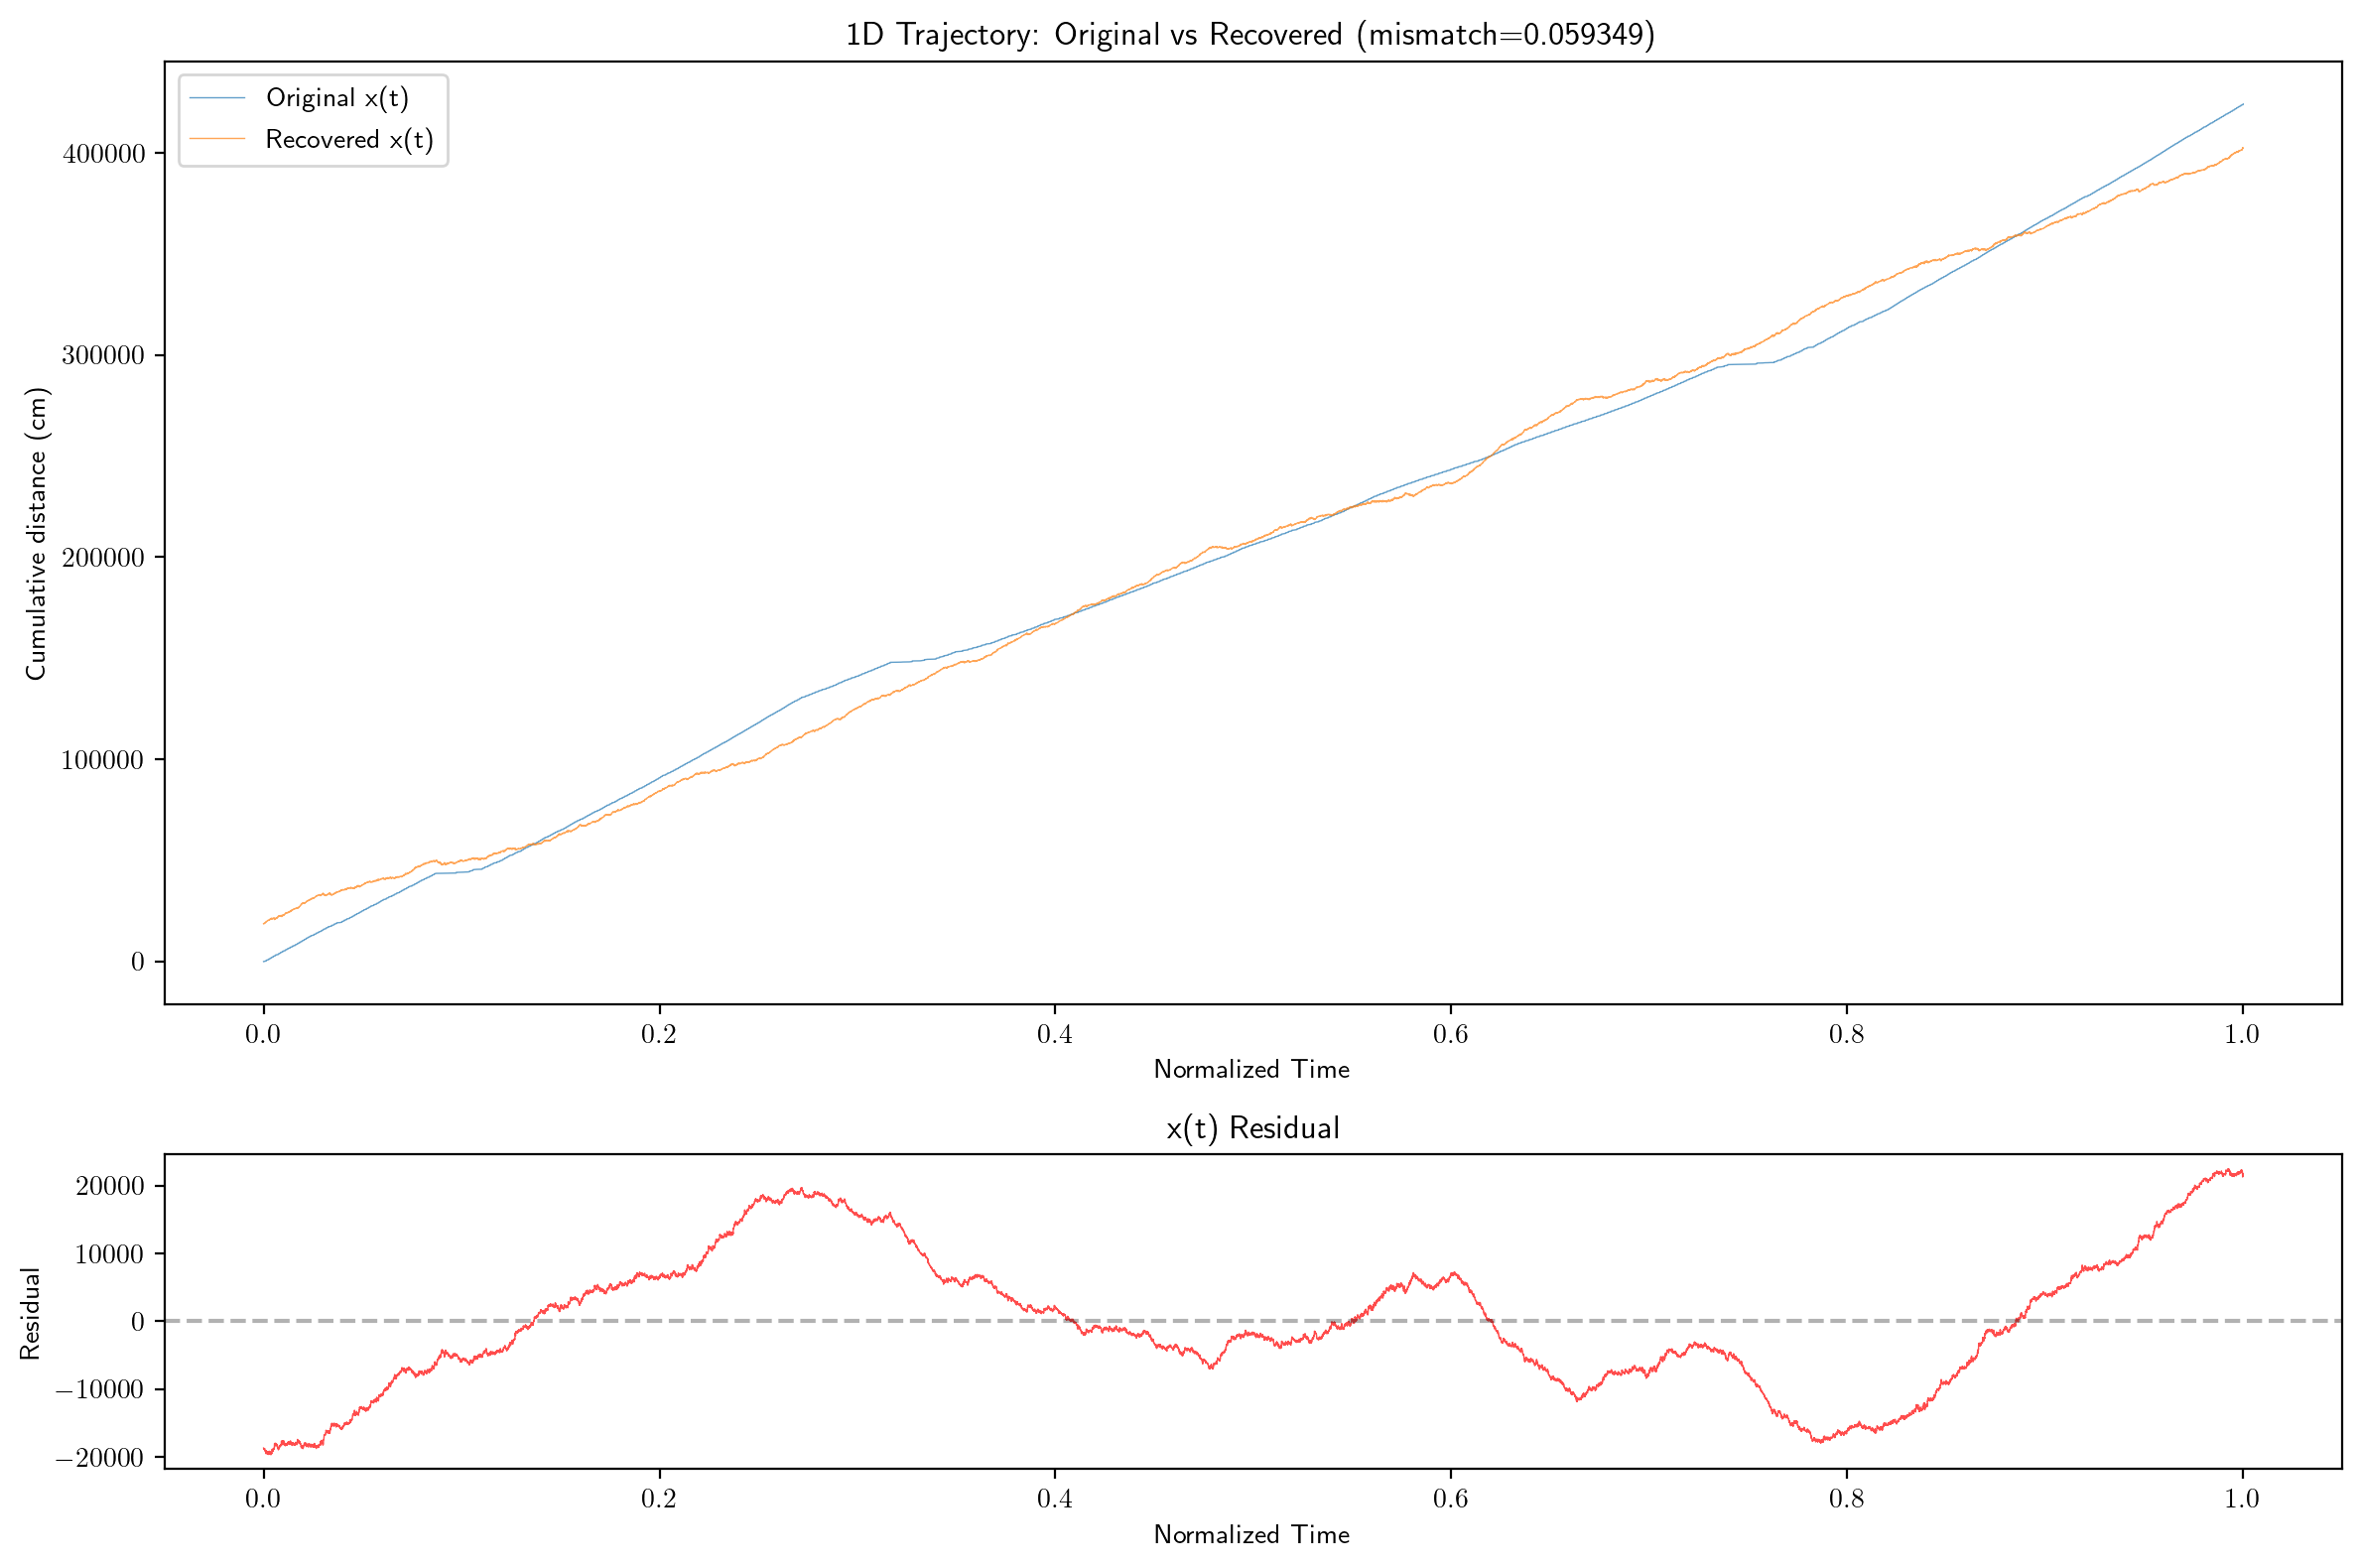

In [34]:
# Plot time vs x: 2D affine transform from lifted to (time, x), then plot x component
post_interp = interp_arr(post, lifted.shape[0])
time_x_target = np.column_stack((post_interp, cumulative_dist_interp))

n_pts = len(time_x_target)
t_norm = np.linspace(0, 1, n_pts)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), height_ratios=[3, 1])

ax1.plot(t_norm, time_x_target[:, 1], label='Original x(t)', alpha=0.7, linewidth=0.5)
ax1.plot(t_norm, lifted_coord_transformed[:, 1], label='Recovered x(t)', alpha=0.7, linewidth=0.5)
ax1.set_xlabel('Normalized Time')
ax1.set_ylabel('Cumulative distance (cm)')
ax1.set_title(f'1D Trajectory: Original vs Recovered (mismatch={overall_score:.6f})')
ax1.legend()

# Residual
residual = time_x_target[:, 1] - lifted_coord_transformed[:, 1]
ax2.plot(t_norm, residual, color='red', alpha=0.7, linewidth=0.5)
ax2.axhline(0, color='black', linestyle='--', alpha=0.3)
ax2.set_xlabel('Normalized Time')
ax2.set_ylabel('Residual')
ax2.set_title('x(t) Residual')

plt.tight_layout()
plt.show()